In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [2]:
cp = pd.read_csv(r"C:\Users\DELL\Downloads\Churn_Dateset_new.csv")

In [3]:
cp.head(5)

,Anonymous Customer ID,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Tariff Plan,Status,Churn,Customer Value
0,1.0,8.0,0.0,38.0,0.0,4370.0,71.0,5.0,17.0,3.0,1.0,1.0,0.0,132.60
1,2.0,0.0,0.0,39.0,0.0,318.0,5.0,7.0,4.0,2.0,1.0,2.0,0.0,17.46
2,3.0,10.0,0.0,37.0,0.0,2453.0,60.0,359.0,24.0,3.0,1.0,1.0,0.0,181.29
3,4.0,10.0,0.0,38.0,0.0,4198.0,66.0,1.0,35.0,1.0,1.0,1.0,0.0,252.48
4,5.0,3.0,0.0,38.0,0.0,2393.0,58.0,2.0,33.0,1.0,1.0,1.0,0.0,144.78


In [4]:
cp.info ()

<class 'pandas.DataFrame'>
RangeIndex: 3157 entries, 0 to 3156
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Anonymous Customer ID    3150 non-null   float64
 1   Call  Failure            3150 non-null   float64
 2   Complains                3150 non-null   float64
 3   Subscription  Length     3150 non-null   float64
 4   Charge  Amount           3150 non-null   float64
 5   Seconds of Use           3150 non-null   float64
 6   Frequency of use         3150 non-null   float64
 7   Frequency of SMS         3150 non-null   float64
 8   Distinct Called Numbers  3150 non-null   float64
 9   Age Group                3150 non-null   float64
 10  Tariff Plan              3150 non-null   float64
 11  Status                   3150 non-null   float64
 12  Churn                    3150 non-null   float64
 13  Customer Value           3150 non-null   float64
dtypes: float64(14)
memory usage: 345.4 

In [5]:
cp.columns

Index(['Anonymous Customer ID', 'Call  Failure', 'Complains',
       'Subscription  Length', 'Charge  Amount', 'Seconds of Use',
       'Frequency of use', 'Frequency of SMS', 'Distinct Called Numbers',
       'Age Group', 'Tariff Plan', 'Status', 'Churn', 'Customer Value'],
      dtype='str')

In [6]:
cp.shape

(3157, 14)

In [7]:
cp.isnull().sum()

Anonymous Customer ID      7
Call  Failure              7
Complains                  7
Subscription  Length       7
Charge  Amount             7
Seconds of Use             7
Frequency of use           7
Frequency of SMS           7
Distinct Called Numbers    7
Age Group                  7
Tariff Plan                7
Status                     7
Churn                      7
Customer Value             7
dtype: int64

In [8]:
cp = cp.drop('Anonymous Customer ID',axis =1)

In [9]:
cp['Call  Failure'] = cp['Call  Failure'].fillna(cp['Call  Failure'].median())
cp['Complains'] = cp['Complains'].fillna(cp['Complains'].mode()[0])
cp['Subscription  Length'] = cp['Subscription  Length'].fillna(cp['Subscription  Length'].median())
cp['Charge  Amount'] = cp['Charge  Amount'].fillna(cp['Charge  Amount'].median())
cp['Seconds of Use'] = cp['Seconds of Use'].fillna(cp['Seconds of Use'].mode()[0])
cp['Frequency of use'] = cp['Frequency of use'].fillna(cp['Frequency of use'].median())
cp['Frequency of SMS'] = cp['Frequency of SMS'].fillna(cp['Frequency of SMS'].mode()[0])
cp['Distinct Called Numbers'] = cp['Distinct Called Numbers'].fillna(cp['Distinct Called Numbers'].median())
cp['Age Group'] = cp['Age Group'].fillna(cp['Age Group'].median())
cp['Tariff Plan'] = cp['Tariff Plan'].fillna(cp['Tariff Plan'].mode()[0])
cp['Status'] = cp['Status'].fillna(cp['Status'].mode()[0])
cp['Customer Value'] = cp['Customer Value'].fillna(cp['Customer Value'].median())

In [12]:
cp = cp.dropna(subset=['Churn'])

In [13]:
cp.isnull().sum()

Call  Failure              0
Complains                  0
Subscription  Length       0
Charge  Amount             0
Seconds of Use             0
Frequency of use           0
Frequency of SMS           0
Distinct Called Numbers    0
Age Group                  0
Tariff Plan                0
Status                     0
Churn                      0
Customer Value             0
dtype: int64

In [57]:
import seaborn as sns
import matplotlib.pyplot as plt

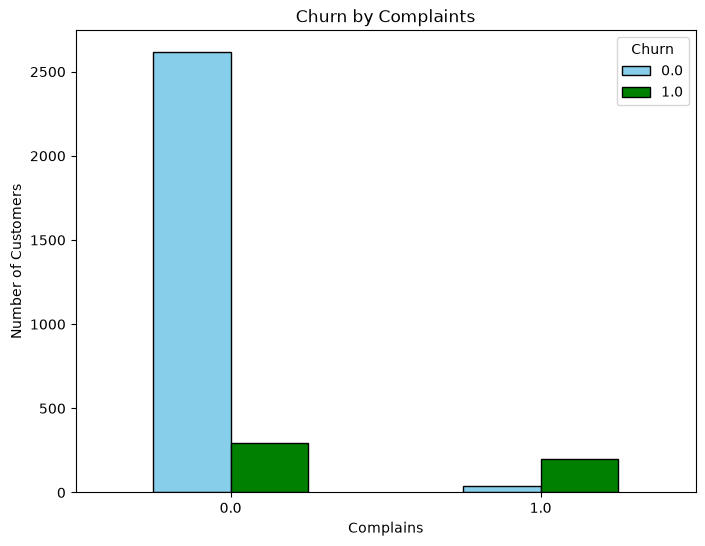

In [61]:
complaint_churn = pd.crosstab(cp['Complains'], cp['Churn'])
complaint_churn.plot(kind='bar',figsize=(8,6),color=('skyblue','Green'),edgecolor=('black'))

plt.title('Churn by Complaints')
plt.xlabel('Complains')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)

plt.show() 

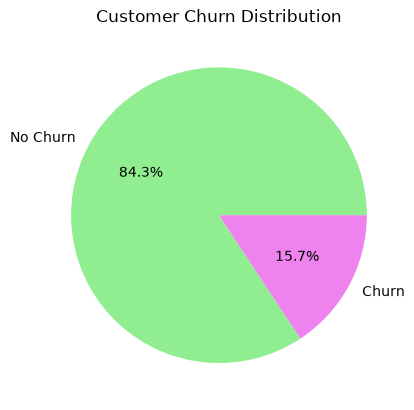

In [58]:
churn_count = cp['Churn'].value_counts()
plt.pie (churn_count, labels=['No Churn', 'Churn'], autopct='%1.1f%%', colors=['lightgreen', 'violet'])
plt.title('Customer Churn Distribution')
plt.show()                   
### No Churn --> Green & Churn --> Purple

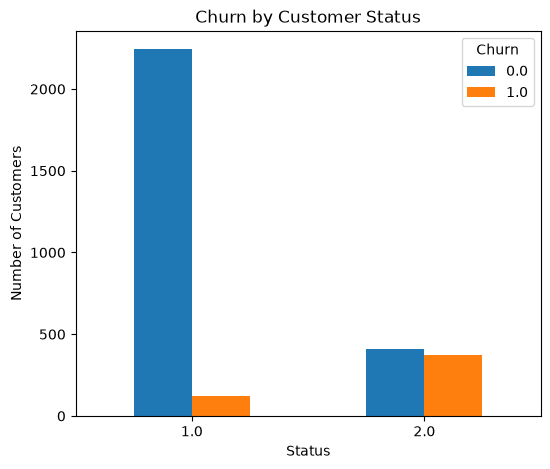

In [63]:
status_churn = pd.crosstab(cp['Status'], cp['Churn'])

status_churn.plot(kind='bar',figsize=(6,5))
plt.title('Churn by Customer Status')
plt.xlabel('Status')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)

plt.show()

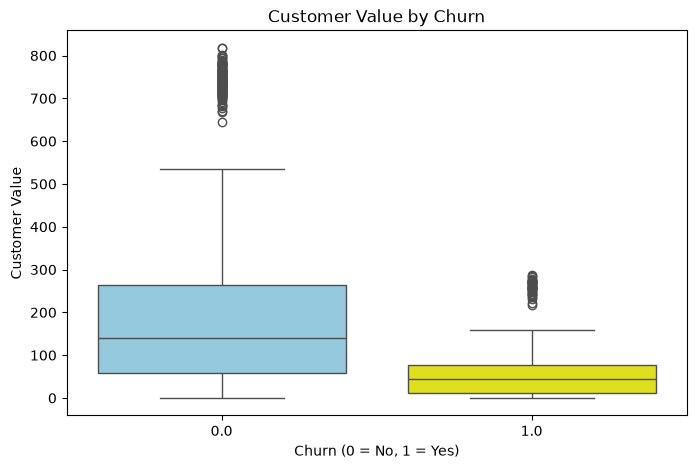

In [64]:
plt.figure(figsize=(8,5))

sns.boxplot(x='Churn',y='Customer Value', data = cp, palette=['Skyblue', 'Yellow'])

plt.title('Customer Value by Churn')
plt.xlabel('Churn (0 = No, 1 = Yes)') ##Blue --> No churn Yellow--->Churn (1)
plt.ylabel('Customer Value')
plt.show()

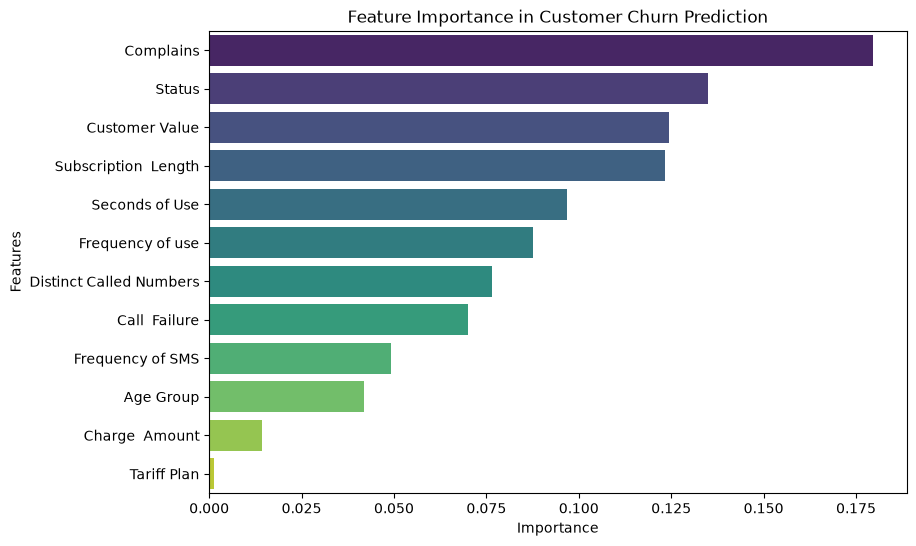

In [83]:
feature_importance = pd.DataFrame({ 'Feature': cp_train_x.columns,'Importance': rf.feature_importances_})
feature_importance = feature_importance.sort_values(by='Importance',ascending=False)
plt.figure(figsize=(9,6))

sns.barplot( x='Importance', y='Feature', data=feature_importance,palette='viridis')
plt.title('Feature Importance in Customer Churn Prediction')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.show()

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, recall_score, precision_score,f1_score

In [15]:
cp_train , cp_test =  train_test_split (cp, test_size= .2, random_state= 123)

cp_train_x = cp_train.drop('Churn', axis =1)
cp_test_x = cp_test.drop('Churn', axis =1)

cp_train_y = cp_train['Churn']
cp_test_y = cp_test['Churn']

In [84]:
# Features expected by the model
features = cp_train_x.columns.tolist()

print("Features expected by the model:")
for feature in features:
    print(feature)

Features expected by the model:
Call  Failure
Complains
Subscription  Length
Charge  Amount
Seconds of Use
Frequency of use
Frequency of SMS
Distinct Called Numbers
Age Group
Tariff Plan
Status
Customer Value


In [72]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
rf.fit(cp_train_x,cp_train_y)
pred = rf.predict(cp_test_x)
tab = confusion_matrix(cp_test_y, pred)
print(tab)

[[513  15]
 [ 18  84]]


In [66]:
print(classification_report(cp_test_y,pred))

              precision    recall  f1-score   support

         0.0       0.97      0.97      0.97       528
         1.0       0.86      0.83      0.85       102

    accuracy                           0.95       630
   macro avg       0.91      0.90      0.91       630
weighted avg       0.95      0.95      0.95       630



In [87]:
import pickle

# Save the model and feature list
model_data = {'model': rf,'features': cp_train_x.columns.tolist()}

with open('rf_model.pkl', 'wb') as file:
    pickle.dump(model_data, file)

print("Model saved successfully as rf_model.pkl")

Model saved successfully as rf_model.pkl


In [88]:
pwd

'C:\\Users\\DELL\\Downloads\\Churn_Project'